In [47]:
import cv2
import numpy as np
import urllib.request
import os
from google.colab.patches import cv2_imshow

In [48]:
urllib.request.urlretrieve('https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov3.weights', 'yolov3.weights')

('yolov3.weights', <http.client.HTTPMessage at 0x7acafd7c62a0>)

In [49]:
urllib.request.urlretrieve('https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg', 'yolov3.cfg')


('yolov3.cfg', <http.client.HTTPMessage at 0x7acafd7c4650>)

In [50]:
urllib.request.urlretrieve('https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names', 'coco.names')


('coco.names', <http.client.HTTPMessage at 0x7acafd7c6a80>)

In [51]:
with open('coco.names', 'r') as f:
    classes = [line.strip() for line in f.readlines()]


In [52]:
net = cv2.dnn.readNet('yolov3.cfg', 'yolov3.weights')
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]


In [53]:
def preprocess_image(image_path, target_size=(416, 416)):

    image = cv2.imread(image_path)
    height, width = image.shape[:2]
    blob = cv2.dnn.blobFromImage(image, 1/255.0, target_size,swapRB=True, crop=False)

    return image, blob, (width, height)

In [54]:
def detect_objects(net, blob, output_layers, conf_threshold=0.5):
    net.setInput(blob)
    outputs = net.forward(output_layers)
    boxes = []
    confidences = []
    class_ids = []

    for output in outputs:
        for detection in output:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > conf_threshold:
                center_x = detection[0]
                center_y = detection[1]
                w = detection[2]
                h = detection[3]

                boxes.append([center_x, center_y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    return boxes, confidences, class_ids

In [55]:
def apply_nms(boxes, confidences, class_ids, width, height,
              conf_threshold=0.5, nms_threshold=0.4):
    opencv_boxes = []
    for box in boxes:
        center_x, center_y, w, h = box

        center_x = int(center_x * width)
        center_y = int(center_y * height)
        w = int(w * width)
        h = int(h * height)
        x = int(center_x - w / 2)
        y = int(center_y - h / 2)

        opencv_boxes.append([x, y, w, h])

    indices = cv2.dnn.NMSBoxes(opencv_boxes, confidences,conf_threshold, nms_threshold)

    final_boxes = []
    final_confidences = []
    final_class_ids = []

    if len(indices) > 0:
        for i in indices.flatten():
            final_boxes.append(opencv_boxes[i])
            final_confidences.append(confidences[i])
            final_class_ids.append(class_ids[i])

    return final_boxes, final_confidences, final_class_ids

In [56]:
def draw_detections(image, boxes, confidences, class_ids, classes):
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(len(classes), 3), dtype='uint8')

    for i in range(len(boxes)):
        x, y, w, h = boxes[i]
        label = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
        color = [int(c) for c in colors[class_ids[i]]]
        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)

        label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]
        label_y = y - 10 if y - 10 > 10 else y + 10

        cv2.rectangle(image, (x, label_y - label_size[1] - 4),
                     (x + label_size[0], label_y + 4), color, -1)
        cv2.putText(image, label, (x, label_y),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    return image

Detected 13 objects before NMS
Detected 4 objects after NMS



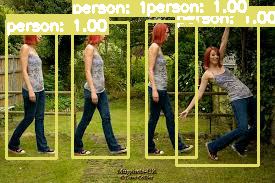

In [57]:
sample_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSs47zE6IyzcAFwxjtq0-kOkULiHzSKy6gm_w&s'
urllib.request.urlretrieve(sample_url, 'sample_image.jpg')
image, blob, (width, height) = preprocess_image('sample_image.jpg')

boxes, confidences, class_ids = detect_objects(net, blob, output_layers,
                                                conf_threshold=0.5)
print(f"Detected {len(boxes)} objects before NMS")

final_boxes, final_confidences, final_class_ids = apply_nms(
    boxes, confidences, class_ids, width, height,
    conf_threshold=0.5, nms_threshold=0.4
)
print(f"Detected {len(final_boxes)} objects after NMS")
print()
result_image = draw_detections(image, final_boxes, final_confidences,
                                final_class_ids, classes)

output_path = 'result.jpg'
cv2.imwrite(output_path, result_image)

cv2_imshow(result_image)


Q- What is the trade-off of resizing? If you shrink an image of a
crowded street too much to make it faster, what critical information
might you lose?

A- Processing the smaller image is faster so resizing improve speed and

if we shrink an image of a crowded street too much to make it faster,then information of the image may be lost or it can be blurred

---

Q- When would grayscaling be a bad idea? Name a detection task
where color is the most important feature. (e.g., identifying traffic
light status, sorting ripe vs. unripe fruit).

A- grayscaling be a bad idea when detection task is depend on the color like traffic like detection.

---

Q- Blurring intentionally destroys information. Imagine you are building a
system to read license plates from a security camera. How could blurring be
helpful? How could it be harmful if you apply too much?

A- it is helpfull because it can reduce random noise and smoothing the image. but it can be harmful if apply too much because it can make image unreadable.

---